In [2]:
from pathlib import Path

import pandas as pd
from torch import tensor

DIRECTORY = Path('C:/Users/Admin/Desktop/logging_file/')
DATA_PATH = DIRECTORY / 'logging_file'

In [58]:
subject_df = pd.read_csv(DIRECTORY / 'domain_masked_wrong_answer.csv')
subject_df.rename(columns={'Label': 'label'}, inplace=True)
subject_df = subject_df['Subject']
subject_df.info()

<class 'pandas.core.series.Series'>
RangeIndex: 2107 entries, 0 to 2106
Series name: Subject
Non-Null Count  Dtype 
--------------  ----- 
2107 non-null   object
dtypes: object(1)
memory usage: 16.6+ KB


In [59]:
domain_df = pd.read_csv(DATA_PATH / 'llama3.1_8b_logging_file_domain.csv')
domain_df['label'] = domain_df['label'].astype('string')
domain_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2107 entries, 0 to 2106
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   predict  2107 non-null   object 
 1   label    2107 non-null   string 
 2   score    2107 non-null   float64
dtypes: float64(1), object(1), string(1)
memory usage: 49.5+ KB


In [62]:
df = pd.concat([domain_df, subject_df], axis=1)
df.to_csv(DIRECTORY / 'llama3.1_8b_subject.csv', index=False)

In [83]:
df = pd.read_csv(DIRECTORY / 'llama3.1_8b_subject.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2107 entries, 0 to 2106
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   predict  2107 non-null   object 
 1   label    2107 non-null   object 
 2   score    2107 non-null   float64
 3   Subject  2107 non-null   object 
dtypes: float64(1), object(3)
memory usage: 66.0+ KB


In [66]:
import re 

def check_number_latex(string):
    text = re.search(r"[0-9$]+", string)
    return text is not None

In [99]:
threshold = 0.45
df['num'] = df['predict'].astype('str').apply(check_number_latex)
cond = (df['score'] > threshold) & (df['num'] == False)
df['retained'] = True
df.loc[cond, 'retained'] = False
df[cond]

,predict,label,score,Subject,num,retained
14,Tình đoàn kết.,Tình đồng chí.,0.5000,civic_education,False,False
18,Gia đình bà E không quan tâm đến các hoạt động...,Gia đình bà E tích cực tham gia các hoạt động ...,0.5000,civic_education,False,False
23,Cảnh cáo.,Cảnh cáo.,1.0000,civic_education,False,False
36,Chiếm hữu của chủ sở hữu và chiếm hữu của ngườ...,Chiếm hữu của chủ sở hữu.,0.6154,civic_education,False,False
37,Quyền tặng cho.,Quyền chiếm hữu.,0.6000,civic_education,False,False
...,...,...,...,...,...,...
2090,Tá tràng.,Kết tràng.,0.5000,biology,False,False
2096,Trứng – ếch non – ếch trưởng thành,Trứng - ếch trưởng thành – nòng nọc,0.6364,biology,False,False
2099,Da có khả năng hấp thụ nước từ môi trường.,Hậu thận và trực tràng có khả năng hấp thụ lại...,0.5000,biology,False,False
2102,Số lượng loài],Số lượng loài trong quần thể.,0.7273,biology,False,False


In [101]:
retain_df = df[~cond]
retain_df

,predict,label,score,Subject,num,retained
0,Cảnh báo hoặc ngăn chặn A để tránh tiếp tục hà...,Cùng với A đánh B cho vui.,0.1667,civic_education,False,True
1,Liên hệ với cơ quan chức năng hoặc người có tr...,Đèo em bé đó đến gặp công an.,0.0000,civic_education,False,True
2,"Người có tính cách linh hoạt, dễ thích nghi.]",Không tôn trọng lẽ phải.,0.0000,civic_education,False,True
3,"Làm giàu bằng chính sức lực, tài năng của mình]",Nhiệt tình giúp đỡ mọi người mà không tính toá...,0.0000,civic_education,False,True
4,Liêm chính.,Khiêm tốn.,0.2500,civic_education,False,True
...,...,...,...,...,...,...
2100,"Thỏ là động vật có túi, không phải là động vật...",Ăn thức ăn bằng cách gặm nhấm.,0.0000,biology,False,True
2101,Cua biển.,Ốc sên.,0.0000,biology,False,True
2103,Chim bồ câu.,Rùa núi vàng.,0.0000,biology,False,True
2104,Màng bụng và màng sinh sản có khả năng hấp thụ...,Da có lớp vảy sừng bao bọc.,0.0769,biology,False,True


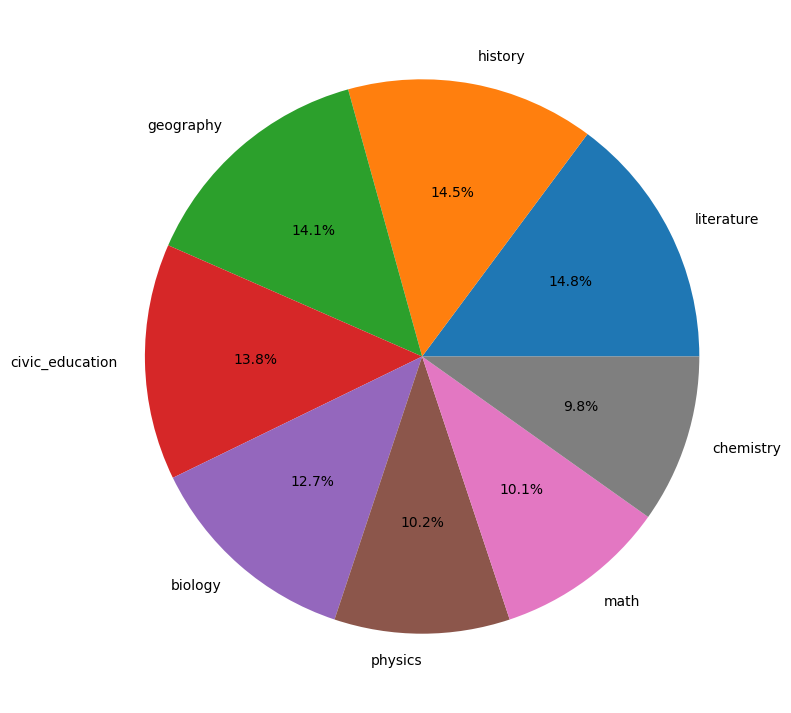

In [109]:


fig = plt.figure(figsize = (16, 9))

plt.pie(retain_df['Subject'].value_counts(), labels = retain_df['Subject'].value_counts().index, autopct='%1.1f%%')
plt.savefig(DIRECTORY / 'llama3.1_8b_subject_pie.png')

In [10]:

df

,predict,label,score,Subject,retained
0,Can ngăn A và giúp B.,Cùng với A đánh B cho vui.,0.3077,civic_education,True
1,Gọi điện cho gia đình của em đó và nhờ sự giúp...,Đèo em bé đó đến gặp công an.,0.1667,civic_education,True
2,Không trung thực.,Không tôn trọng lẽ phải.,0.2500,civic_education,True
3,"Làm giàu bằng chính sức lực, tài năng của mình",Nhiệt tình giúp đỡ mọi người mà không tính toá...,0.0000,civic_education,True
4,Chính trực.,Khiêm tốn.,0.0000,civic_education,True
...,...,...,...,...,...
2102,Số lượng cá thể trong quần xã.,Số lượng loài trong quần thể.,0.6154,biology,False
2103,Cá voi.,Rùa núi vàng.,0.0000,biology,True
2104,Da có tuyến nhờn.,Da có lớp vảy sừng bao bọc.,0.3636,biology,True
2105,Do các loại dịch bệnh bất thường.,Do các loại thiên tai xảy ra.,0.4286,biology,False


In [8]:
import matplotlib.pyplot as plt

<BarContainer object of 8 artists>

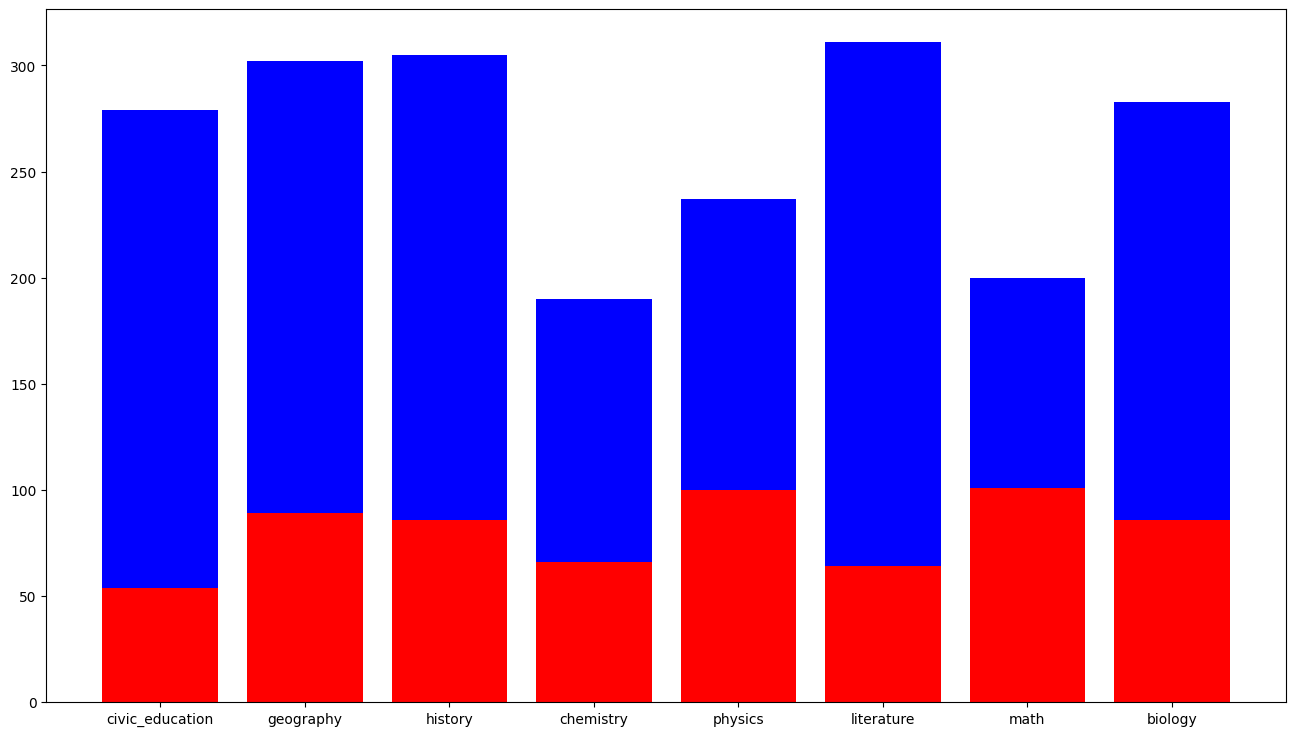

In [45]:
df = pd.read_csv(DIRECTORY / 'filtered_data/vistral_7b_mini_logging_file_domain.csv')

fig = plt.figure(figsize = (16, 9))
count = {}
count_drop = {}
for key in df['Subject'].unique():
    count[key] = [df[df['Subject'] == key].shape[0]]
    count_drop[key] = [df[(df['Subject'] == key) & (df['retained'] == False)].shape[0]]

count = pd.DataFrame.from_dict(count, orient='index')
count_drop = pd.DataFrame.from_dict(count_drop, orient='index')
plt.bar(count.index, count[0], color = 'b')
plt.bar(count_drop.index, count_drop[0], color = 'r')

In [46]:
df[df['retained'] == True]['Subject'].value_counts()

Subject
literature         247
civic_education    225
history            219
geography          213
biology            197
physics            137
chemistry          124
math                99
Name: count, dtype: int64

In [44]:
df[df['Subject'] == 'math']

,predict,label,score,Subject,retained
1624,101,525,0.2500,math,False
1625,700 + 20 + 8,700 + 2,0.8000,math,False
1626,0 chia cho số nào không bằng chính số đó.,Số nào nhân với 0 cũng bằng 0.,0.5200,math,False
1627,70,90,0.6667,math,False
1628,Đô,Một năm,0.0000,math,True
...,...,...,...,...,...
1819,Điểm nằm,Trong tam giác,0.0000,math,False
1820,4,4,1.0000,math,False
1821,"Để xấp dân giả, chúng ta phải tìm hiểu sự liên...","(x = y−1, y ∈ R)",0.0930,math,False
1822,1,100,0.6667,math,True


In [48]:
df[df['predict'] == df['label']]

,predict,label,score,Subject,retained
45,Hai điều kiện,Hai điều kiện,1.0,civic_education,True
151,1986,1986,1.0,civic_education,False
156,Biển báo nguy hiểm.,Biển báo nguy hiểm.,1.0,civic_education,True
164,"Điều 22, Hiến pháp 2013.","Điều 22, Hiến pháp 2013.",1.0,civic_education,False
166,2,2,1.0,civic_education,False
...,...,...,...,...,...
1971,3,3,1.0,biology,False
1976,2,2,1.0,biology,True
1996,Phổi.,Phổi.,1.0,biology,False
2032,"0,3 và 0,7","0,3 và 0,7",1.0,biology,False


In [49]:
ddf = pd.read_csv(DIRECTORY / 'domain_masked_wrong_answer.csv')
ddf

,Question,Fed_Prompt,Label,Choosed_wrong_answer,True_answer,Subject
0,"### Câu hỏi: Trong giờ ra chơi, A trêu đùa và ...","Trong giờ ra chơi, A trêu đùa và đánh B gây ch...",Cùng với A đánh B cho vui.,C,A,civic_education
1,### Câu hỏi: Trên đường đi học về em nhìn thấy...,Trên đường đi học về em nhìn thấy một thanh ni...,Đạp thật nhanh về nhà.,D,B,civic_education
2,### Câu hỏi: Câu thành ngữ: Gió chiều nào theo...,Câu thành ngữ: Gió chiều nào theo chiều ấy nói...,Không tôn trọng lẽ phải.,A,C,civic_education
3,### Câu hỏi: Em rèn tính liêm khiết trong học ...,Em rèn tính liêm khiết trong học tập là:\nA. N...,"Làm giàu bằng chính sức lực, tài năng của mình",B,D,civic_education
4,"### Câu hỏi: Không hám danh, hám lợi, không nh...","Không hám danh, hám lợi, không nhỏ nhen, ích k...",Khiêm tốn.,D,A,civic_education
...,...,...,...,...,...,...
2102,### Câu hỏi: Tiêu chí nào dưới đây biểu thị sự...,Tiêu chí nào dưới đây biểu thị sự đa dạng sinh...,Số lượng cá thể trong quần xã.,B,C,biology
2103,### Câu hỏi: Động vật nào dưới đây thụ tinh ng...,Động vật nào dưới đây thụ tinh ngoài?\nA. Cá c...,Thỏ hoang.,D,A,biology
2104,### Câu hỏi: Đặc điểm nào dưới đâu giúp cơ thể...,Đặc điểm nào dưới đâu giúp cơ thể thằn lằn giữ...,Hậu thận và trực tràng có khả năng hấp thụ lại...,C,D,biology
2105,"### Câu hỏi: Trong các nguyên nhân sau, đâu là...","Trong các nguyên nhân sau, đâu là nguyên nhân ...",Do khả năng thích nghi của sinh vật bị suy giả...,C,A,biology


In [53]:
def EM():
    data_list = list(DATA_PATH.iterdir())
    data_list = [x.name for x in data_list if x.stem != 'data']
    for data in data_list:
        df = pd.read_csv(DATA_PATH / data)
        print(data, len(df[df['label'] == df['predict']]))
EM()

gemma2_9b_logging_file_domain.csv 93
llama3.1_8b_logging_file_domain.csv 61
llama3.1_8b_logging_file_mmlu.csv 113
phi3.5_mini_logging_file_domain.csv 36
phi3.5_mini_logging_file_mmlu.csv 38
qwen2_7b_logging_file_domain.csv 53
qwen2_7b_logging_file_mmlu.csv 56
vistral_7b_mini_logging_file_domain.csv 110
vistral_7b_mini_logging_file_mmlu.csv 67
